In [6]:
import pandas as pd
import matplotlib.pyplot as plt

day = 0

print("PRICES")
prices_df = pd.read_csv(f'data/prices_round_1_day_{day}.csv', delimiter=';')
print(prices_df.head())

print("TRADES")
trades_df = pd.read_csv(f'data/trades_round_1_day_{day}.csv', delimiter=';')
print(trades_df.head())

PRICES
   day  timestamp               product  bid_price_1  bid_volume_1  \
0    0          0     ASH_COATED_OSMIUM          NaN           NaN   
1    0          0  INTARIAN_PEPPER_ROOT      11991.0          19.0   
2    0        100  INTARIAN_PEPPER_ROOT      11994.0           9.0   
3    0        100     ASH_COATED_OSMIUM       9995.0          13.0   
4    0        200  INTARIAN_PEPPER_ROOT      11991.0          20.0   

   bid_price_2  bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  \
0          NaN           NaN          NaN           NaN      10013.0   
1          NaN           NaN          NaN           NaN      12006.0   
2      11991.0          23.0          NaN           NaN      12007.0   
3          NaN           NaN          NaN           NaN      10011.0   
4          NaN           NaN          NaN           NaN      12007.0   

   ask_volume_1  ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  \
0          30.0          NaN           NaN          NaN           

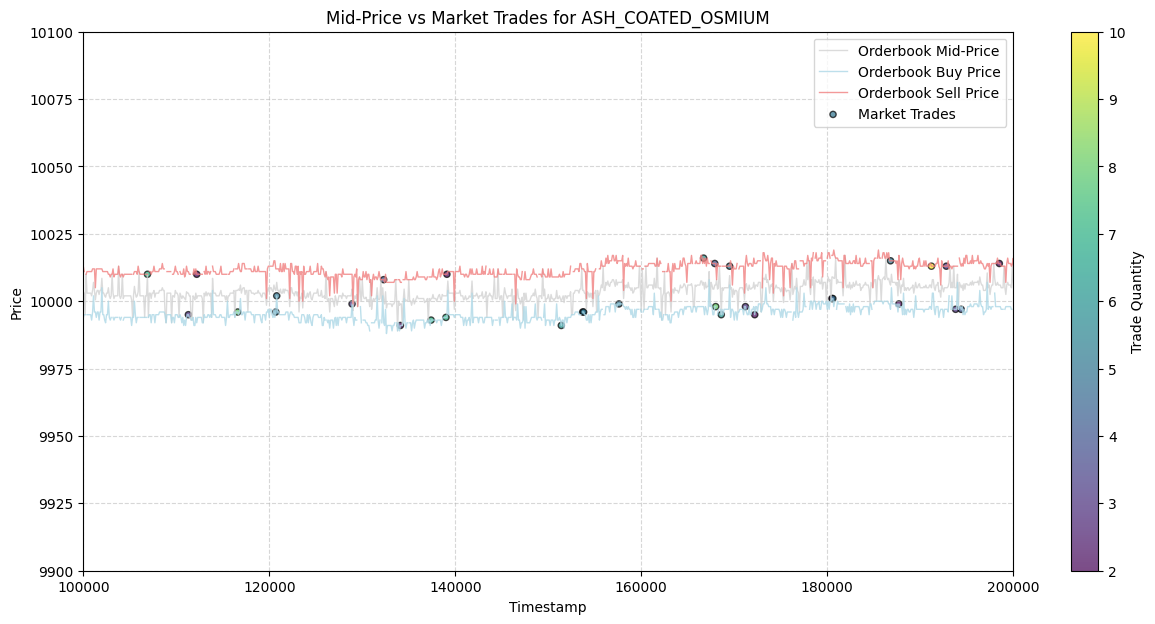

In [21]:
product = 'ASH_COATED_OSMIUM'
prod_prices = prices_df[prices_df['product'] == product].copy()
prod_trades = trades_df[trades_df['symbol'] == product].copy()

plt.figure(figsize=(15, 7))

# Plot the Mid-Price line
plt.plot(prod_prices['timestamp'], prod_prices['mid_price'], 
         label='Orderbook Mid-Price', color='lightgray', alpha=0.8, linewidth=1)


plt.plot(prod_prices['timestamp'], prod_prices['bid_price_1'], 
         label='Orderbook Buy Price', color='lightblue', alpha=0.8, linewidth=1)

plt.plot(prod_prices['timestamp'], prod_prices['ask_price_1'], 
         label='Orderbook Sell Price', color='lightcoral', alpha=0.8, linewidth=1)

# Overlay the Market Trades
plt.scatter(prod_trades['timestamp'], prod_trades['price'], 
            c=prod_trades['quantity'], cmap='viridis', label='Market Trades', 
            s=20, edgecolors='black', alpha=0.7)

plt.ylim(9900, 10100)
plt.xlim(1e5, 2e5)

plt.colorbar(label='Trade Quantity')
plt.title(f'Mid-Price vs Market Trades for {product}')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.show()